# Stochastic Programming

This notebook was prepared by [Jialu Wang](https://github.com/jialuw96) and revised by [Maddie Watson](https://github.com/MadelynnWatson) at the University of Notre Dame.

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 16 rewritten markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# Imports
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

## Farmer's example: one model, reused

Read the physical balances, connect them to Pyomo Blocks, and analyze complete solution tables. The [SAA](Farmer_SAA.ipynb), [CVaR](Farmer_CVaR.ipynb), and [zero-VSS](Farmer_Zero_VSS.ipynb) pages reuse this implementation. [Further examples](Farmer_Extensions.ipynb) retain the optional uniform-yield, dependence, and profit-floor studies.

Textbook data: Birge and Louveaux (2011), 2nd ed., §1.1a–c, pp. 4–11.

The synthetic farmer example in Birge and Louveaux (2011), 2nd ed., §1.1a–c, pp. 4–11, uses 500 acres and three crops. Wheat and corn must supply 200 and 240 tons of feed; shortages can be purchased and surplus sold. Sugar beets have a premium-price sales cap of 6000 tons. 

|                     	| Wheat   | Corn	| Sugar Beets          	|
|-------------------------|---------|---------|--------------------------|
| **Yield (T/acre)**   	| 2.5 	| 3   	| 20                   	|
| **Planting cost ($/acre)** | 150 	| 230 	| 260                  	|
| **Selling price ($/T)**  | 170 	| 150 	| 36 under 6000 T, 10 above 6000 T |
| **Purchase price ($/T)** | 238 	| 210 	| –                    	|
| **Minimum requirement (T)** | 200 	| 240 	| –                    	|

**Total available land**: 500 acres

To help the farmer make up his mind, we can set up the following model. Let
* $x_1$ = acres of land devoted to wheat, 
* $x_2$ = acres of land devoted to corn, 
* $x_3$ = acres of land devoted to sugar beets,  
* $w_1$ = tons of wheat sold, 
* $y_1$ = tons of wheat purchased,  
* $w_2$ = tons of corn sold,  
* $y_2$ = tons of corn purchased,  
* $w_3$ = tons of sugar beets sold at the favorable price,
* $w_4$ = tons of sugar beets sold at the unfavorable price.


![Farmer's problem: acres allocated to each crop, with required animal feed and quantities sold to or purchased from the market.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/farmer-crop-allocation.png)

### Deterministic mean-yield model 

First solve at the specified mean yields. Later, the same model is solved separately at each realized yield to compute the perfect-information benchmark: 

$$
\begin{align*}
\min \quad & \underbrace{150x_1 + 230x_2 + 260x_3}_{\text{planting costs}} \underbrace{+ 238y_1 - 170w_1}_{\text{wheat purchases less sales}} \\
       	& \underbrace{+ 210y_2 - 150w_2}_\text{corn purchases less sales} ~
		\underbrace{- 36w_3 - 10w_4}_{\text{sugar beet sales}} \\
\text{s.t.} \quad & x_1 + x_2 + x_3 \leq 500, \quad \text{(plant up to 500 acres)} \\
       	& 2.5x_1 + y_1 - w_1 \geq 200, \quad \text{(satisfy wheat demand)}\\
       	& 3x_2 + y_2 - w_2 \geq 240, \quad \text{(satisfy corn demand)}\\
       	& w_3 + w_4 \leq 20x_3, \quad \text{(beet sales cannot exceed production)}\\
       	& w_3 \leq 6000, \quad \text{(cap beet sales at favorable price)}\\
       	& x_1, x_2, x_3, y_1, y_2, w_1, w_2, w_3, w_4 \geq 0.
\end{align*}
$$

### Declare shared decisions and scenario Blocks

A `Block` groups variables, constraints, and expressions. The root model owns
acreage; each scenario Block owns purchases and sales and refers to the **same**
acreage variables. One scenario gives the deterministic LP. More scenarios reuse
the model without copying planting decisions.

The builder and its helpers below are defined before the first solve. Monetary
objectives use **profit maximization**; this is equivalent to minimizing net cost
in the mathematical formulation above. Units are checked on the small models.

In [2]:
import numpy as np
import pyomo.environ as pyo
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent

u.load_definitions_from_strings(["USD = [currency]"])
USD_PER_ACRE = u.USD / u.acre
USD_PER_TON = u.USD / u.metric_ton
TON_PER_ACRE = u.metric_ton / u.acre
CROPS = ["WHEAT", "CORN", "BEETS"]
FEED_CROPS = ["WHEAT", "CORN"]
SALE_TYPES = ["WHEAT", "CORN", "BEETS_FAVORABLE", "BEETS_UNFAVORABLE"]
MEAN_YIELD = dict(zip(CROPS, [2.5, 3.0, 20.0]))  # T/acre
PLANT_COST = dict(zip(CROPS, [150.0, 230.0, 260.0]))  # $/acre
BUY_PRICE = dict(zip(FEED_CROPS, [238.0, 210.0]))  # $/T
SELL_PRICE = dict(zip(SALE_TYPES, [170.0, 150.0, 36.0, 10.0]))  # $/T
FEED_NEED = dict(zip(FEED_CROPS, [200.0, 240.0]))  # T
TOTAL_LAND, BEET_QUOTA = 500.0, 6000.0  # acres, T

In [3]:
def build_farmer(
    scenarios, weights=None, plant_cost=None, risk=None, check_units=False
):
    """Return a fresh farmer model; scenarios contain yields and optional prices.

    scenarios: nonempty list of dictionaries; 'yield' maps crops to T/acre.
    Optional 'buy' and 'sell' mappings give $/T. weights sum to one.
    plant_cost maps crops to $/acre. risk selects the optional Lecture 10 policy.
    """
    n = len(scenarios)
    if n == 0:
        raise ValueError("At least one scenario is required")
    w = np.full(n, 1 / n) if weights is None else np.asarray(weights, float)
    if w.shape != (n,) or not np.all(np.isfinite(w)) or np.any(w <= 0):
        raise ValueError("Retained scenarios need positive finite probabilities")
    if not np.isclose(w.sum(), 1.0):
        raise ValueError("Scenario probabilities must sum to one")
    costs = PLANT_COST if plant_cost is None else plant_cost
    m = pyo.ConcreteModel()
    m.CROPS = pyo.Set(initialize=CROPS)
    m.FEED_CROPS = pyo.Set(initialize=FEED_CROPS)
    m.SALE_TYPES = pyo.Set(initialize=SALE_TYPES)
    m.SCENARIOS = pyo.RangeSet(0, n - 1)
    m.weight = pyo.Param(m.SCENARIOS, initialize=dict(enumerate(w)))
    # Plant once, before learning the yields: no scenario index on acreage.
    m.acreage = pyo.Var(m.CROPS, domain=pyo.NonNegativeReals, units=u.acre)
    m.land_limit = pyo.Constraint(expr=sum(m.acreage.values()) <= TOTAL_LAND * u.acre)
    m.planting_cost = pyo.Expression(
        expr=sum(costs[c] * USD_PER_ACRE * m.acreage[c] for c in CROPS)
    )
    # The helper below attaches recourse to each Block, sharing root acreage.
    m.scenarios = pyo.Block(
        m.SCENARIOS, rule=lambda b, s: add_farmer_scenario(b, m, scenarios[s])
    )
    m.expected_profit = pyo.Expression(
        expr=sum(m.weight[s] * m.scenarios[s].profit for s in m.SCENARIOS)
    )
    m.objective = pyo.Objective(expr=m.expected_profit, sense=pyo.maximize)
    if risk:
        add_farmer_risk(m, risk)  # Optional policies introduced in Lecture 10.
    if check_units:
        assert_units_consistent(m)
    return m

In [4]:
def add_farmer_scenario(b, m, scenario):
    """Attach one scenario's recourse, using the root model's acreage."""
    crop_yield = scenario["yield"]
    buy = scenario.get("buy", BUY_PRICE)
    sell = scenario.get("sell", SELL_PRICE)
    b.purchases = pyo.Var(m.FEED_CROPS, domain=pyo.NonNegativeReals, units=u.metric_ton)
    b.sales = pyo.Var(m.SALE_TYPES, domain=pyo.NonNegativeReals, units=u.metric_ton)
    b.sales["BEETS_FAVORABLE"].setub(BEET_QUOTA)

    # Harvest + purchases - sales must cover animal feed in this scenario.
    @b.Constraint(m.FEED_CROPS)
    def feed_balance(block, c):
        return (
            crop_yield[c] * TON_PER_ACRE * m.acreage[c]
            + block.purchases[c]
            - block.sales[c]
            >= FEED_NEED[c] * u.metric_ton
        )

    b.beets_constraint = pyo.Constraint(
        expr=b.sales["BEETS_FAVORABLE"] + b.sales["BEETS_UNFAVORABLE"]
        <= crop_yield["BEETS"] * TON_PER_ACRE * m.acreage["BEETS"]
    )
    # Profit includes planting cost; weights summing to one count it once.
    b.profit = pyo.Expression(
        expr=sum(sell[k] * USD_PER_TON * b.sales[k] for k in SALE_TYPES)
        - sum(buy[c] * USD_PER_TON * b.purchases[c] for c in FEED_CROPS)
        - m.planting_cost
    )

In [5]:
farmer_solver = pyo.SolverFactory("appsi_highs")
assert farmer_solver.available(), "HiGHS is required for the rest of this notebook"


def solve_farmer(m):
    """Solve, refusing anything but a proven optimum."""
    results = farmer_solver.solve(m)
    assert pyo.check_optimal_termination(
        results
    ), f"Solve failed: termination={results.solver.termination_condition}"
    return m


def plan_of(m):
    """Stage 1 acreage as a plain array, in the order of CROPS."""
    return np.array([pyo.value(m.acreage[c]) for c in CROPS])


In [6]:
def grade_plan(plan, scenarios, weights=None, plant_cost=None):
    """Fix acreage in CROPS order; optimize trades for the supplied scenarios.

    Return expected profit and an array of scenario profits, both in dollars.
    """
    m = build_farmer(scenarios, weights, plant_cost)
    for crop, acres in zip(CROPS, plan):
        m.acreage[crop].fix(acres)
    solve_farmer(m)
    return (
        pyo.value(m.expected_profit),
        np.array([pyo.value(m.scenarios[i].profit) for i in m.SCENARIOS]),
    )


In [7]:
def correlated_scenario(multiplier):
    """One scenario of Section 1.1b: every crop scaled by the same factor."""
    return {"yield": {c: MEAN_YIELD[c] * multiplier for c in CROPS}}


# The three equally likely scenarios of Section 1.1b
THREE = [correlated_scenario(f) for f in (1.2, 1.0, 0.8)]

### Shared helpers for the companion pages

The optional risk interface and complete-solution utilities below are also exported from this notebook. Lecture 9 uses the default expected-profit objective; [CVaR](Farmer_CVaR.ipynb) explains the risk formulation.

In [8]:
def add_farmer_cvar(m, risk):
    """Lower-tail profit CVaR: alpha is the confidence level."""
    w = m.weight
    n = len(m.SCENARIOS)
    # Rockafellar-Uryasev epigraph, B&L (9.8)-(9.10), p. 85, written for the
    # LOWER tail of profit: CVaR_a = max_nu { nu - E[(nu - profit)_+]/(1-a) }
    alpha = (risk.get("cvar") or risk.get("cvar_floor"))[0]
    m.nu = pyo.Var(domain=pyo.Reals, units=u.USD)
    m.shortfall = pyo.Var(m.SCENARIOS, domain=pyo.NonNegativeReals, units=u.USD)
    m.shortfall_con = pyo.Constraint(
        m.SCENARIOS,
        rule=lambda m, i: m.shortfall[i] >= m.nu - m.scenarios[i].profit,
    )
    m.cvar = m.nu - (1.0 / (1.0 - alpha)) * sum(w[i] * m.shortfall[i] for i in range(n))
    if "cvar_floor" in risk:
        m.cvar_con = pyo.Constraint(expr=m.cvar >= risk["cvar_floor"][1] * u.USD)

In [9]:
def add_farmer_risk(m, risk):
    """Attach the requested risk policy to a fresh farmer model."""
    w = m.weight
    n = len(m.SCENARIOS)
    m.del_component(m.objective)
    if "floor" in risk:
        # Exercise 7(b): a profit floor imposed in every scenario
        m.profit_floor = pyo.Constraint(
            m.SCENARIOS,
            rule=lambda m, i: m.scenarios[i].profit >= risk["floor"] * u.USD,
        )
    if "minimax" in risk:
        # B&L (9.15), p. 86, in profit form: maximize the worst scenario
        m.worst = pyo.Var(domain=pyo.Reals, units=u.USD)
        m.worst_con = pyo.Constraint(
            m.SCENARIOS, rule=lambda m, i: m.worst <= m.scenarios[i].profit
        )
    if "cvar" in risk or "cvar_floor" in risk:
        add_farmer_cvar(m, risk)
    if "downside" in risk:
        # Expected downside risk, B&L (5.1)-(5.3), p. 68
        target, level = risk["downside"]
        m.shortfall_below_target = pyo.Var(
            m.SCENARIOS, domain=pyo.NonNegativeReals, units=u.USD
        )
        m.downside_def = pyo.Constraint(
            m.SCENARIOS,
            rule=lambda m, i: m.shortfall_below_target[i]
            >= target * u.USD - m.scenarios[i].profit,
        )
        m.downside_limit = pyo.Constraint(
            expr=sum(w[i] * m.shortfall_below_target[i] for i in range(n))
            <= level * u.USD
        )

    if "minimax" in risk:
        m.objective = pyo.Objective(expr=m.worst, sense=pyo.maximize)
    elif "cvar" in risk:
        lam = risk["cvar"][1]
        m.objective = pyo.Objective(
            expr=(1 - lam) * m.expected_profit + lam * m.cvar, sense=pyo.maximize
        )
    else:
        m.objective = pyo.Objective(expr=m.expected_profit, sense=pyo.maximize)

In [10]:
def synthetic_farmer_yields(n, seed):
    """Draw synthetic joint yields, not observed agricultural data.

    Weather multiplier = 0.65 + 0.70 * Beta(2, 2), shared by all crops.
    Independent crop deviations are Uniform(-0.08, 0.08).
    All crop multipliers lie in [0.57, 1.43], with population mean 1.
    Dependence comes from shared weather; draws across scenarios are iid.
    """
    rng = np.random.default_rng(seed)
    weather = 0.65 + 0.70 * rng.beta(2, 2, size=n)
    multipliers = weather[:, None] + rng.uniform(-0.08, 0.08, size=(n, 3))
    return [{"yield": dict(zip(CROPS, row * np.array(list(MEAN_YIELD.values()))))}
            for row in multipliers]


SYNTHETIC_SEED = 20260927
TWENTY = synthetic_farmer_yields(20, SYNTHETIC_SEED)


def solution_record(m):
    """Full solved policy and recourse, with units explicit in field names."""
    return {
        "acreage": {c: float(pyo.value(m.acreage[c])) for c in CROPS},
        "expected_profit": float(pyo.value(m.expected_profit)),
        "scenarios": [
            {"id": int(i) + 1,
             "probability": float(pyo.value(m.weight[i])),
             "purchases_tons": {c: float(pyo.value(m.scenarios[i].purchases[c]))
                                for c in FEED_CROPS},
             "sales_tons": {c: float(pyo.value(m.scenarios[i].sales[c]))
                            for c in SALE_TYPES},
             "profit": float(pyo.value(m.scenarios[i].profit))}
            for i in m.SCENARIOS],
    }


def evaluate_solution(plan, scenarios, weights=None, plant_cost=None):
    """Return all efficient trades for fixed acreage, not arbitrary risk-solve trades."""
    m = build_farmer(scenarios, weights=weights, plant_cost=plant_cost)
    for c, acres in zip(CROPS, plan):
        m.acreage[c].fix(float(acres))
    return solution_record(solve_farmer(m))


def analytic_profits(plan, scenarios, plant_cost=None):
    """Independent closed-form recourse for these farmer data (dollars).

    Valid when sales prices are nonnegative, purchase prices exceed selling
    prices, and favorable beet revenue exceeds over-quota revenue. Feed
    shortages are bought, surpluses sold; beet sales fill the premium quota first.
    """
    costs = PLANT_COST if plant_cost is None else plant_cost
    acreage = dict(zip(CROPS, plan))
    planting = sum(costs[c] * acreage[c] for c in CROPS)
    profits = []
    for s in scenarios:
        sell, buy = s.get("sell", SELL_PRICE), s.get("buy", BUY_PRICE)
        assert all(buy[c] > sell[c] >= 0 for c in FEED_CROPS)
        assert sell["BEETS_FAVORABLE"] >= sell["BEETS_UNFAVORABLE"] >= 0
        profit = -planting
        for c in FEED_CROPS:
            surplus = s["yield"][c] * acreage[c] - FEED_NEED[c]
            profit += sell[c] * max(surplus, 0) - buy[c] * max(-surplus, 0)
        beets = s["yield"]["BEETS"] * acreage["BEETS"]
        profit += sell["BEETS_FAVORABLE"] * min(beets, BEET_QUOTA)
        profit += sell["BEETS_UNFAVORABLE"] * max(beets - BEET_QUOTA, 0)
        profits.append(profit)
    return np.asarray(profits)


def lower_tail_profit(profits, alpha, weights=None):
    """Average the worst mass 1-alpha, including fractional mass at ties."""
    values = np.asarray(profits, dtype=float)
    if not 0 <= alpha < 1:
        raise ValueError("alpha must be in [0, 1)")
    w = np.full(len(values), 1 / len(values)) if weights is None else np.asarray(weights)
    if len(values) == 0 or w.shape != values.shape or np.any(w < 0) or not np.isclose(w.sum(), 1):
        raise ValueError("Use nonempty outcomes with probabilities summing to one")
    order = np.argsort(values)
    remaining, total = 1 - alpha, 0.0
    for i in order:
        mass = min(float(w[i]), remaining)
        total += mass * values[i]
        remaining -= mass
        if remaining <= 1e-14:
            break
    return total / (1 - alpha)


### Known yields: solve, then interpret

`build_farmer([correlated_scenario(1.0)])` creates the mean-yield LP. The same
function receives a singleton list for each known-yield benchmark below.

**Discuss:** classify the problem. Why does the solution grow 300 acres of beets?
Which resource limits the profit? The dual values report the local change in
optimal profit per extra unit of the corresponding constraint bound.

In [11]:
mean_model = build_farmer([correlated_scenario(1.0)], check_units=True)
mean_model.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
solve_farmer(mean_model)
mean_plan = plan_of(mean_model)
print("Mean-yield acreage [wheat, corn, beets]:", mean_plan)
print(f"Profit: ${pyo.value(mean_model.expected_profit):,.2f}")
print(f"Land multiplier: ${mean_model.dual[mean_model.land_limit]:.2f}/acre")
for c in FEED_CROPS:
    con = mean_model.scenarios[0].feed_balance[c]
    print(f"Feed minimum multiplier, {c}: ${mean_model.dual[con]:.2f}/T")
assert np.allclose(mean_plan, [120, 80, 300])
assert np.isclose(pyo.value(mean_model.expected_profit), 118600)

Mean-yield acreage [wheat, corn, beets]: [120.  80. 300.]
Profit: $118,600.00
Land multiplier: $275.00/acre
Feed minimum multiplier, WHEAT: $-170.00/T
Feed minimum multiplier, CORN: $-168.33/T


The mean-yield model is an LP. Premium beet acreage reaches the sales quota;
corn meets feed needs, and wheat takes the remaining land. The land multiplier
is a **local sensitivity**, not a universal crop ranking. Crop rotation and
shared labor constraints can change the allocation.

### What if yields are known before planting?

Solve three separate problems: all crops at 120%, 100%, or 80% of mean yield.
This assumes perfect information before planting.

In [12]:
perfect_models = [solve_farmer(build_farmer([scenario])) for scenario in THREE]


In [13]:
print("Known yield     wheat     corn    beets       profit ($)")
for label, model in zip(["above", "average", "below"], perfect_models):
    a = plan_of(model)
    print(
        f"{label:12s} {a[0]:8.1f} {a[1]:8.1f} {a[2]:8.1f}"
        f" {pyo.value(model.expected_profit):16,.2f}"
    )

Known yield     wheat     corn    beets       profit ($)
above           183.3     66.7    250.0       167,666.67
average         120.0     80.0    300.0       118,600.00
below           100.0     25.0    375.0        59,950.00


**Analyze the results:** why does lower beet yield lead to more beet acreage?
Why does the bad-year solution buy corn? Which assumption makes these three
planting plans unavailable to a farmer who must plant before observing yields?

### One planting plan, three possible harvests

- Stage 1: choose acreage before yield information.
- Stage 2: buy and sell after observing the harvest.
- **Nonanticipativity:** decisions use only information available at that time.
  One shared `m.acreage` enforces this structurally.

Each scenario has probability 1/3. The same `build_farmer(THREE)` function now
creates three Blocks and maximizes expected profit.

Birge and Louveaux, §1.1b–c, pp. 6–11; §1.2, pp. 21, 25–26.

$$
\begin{align*}
\min \quad & 150x_1 + 230x_2 + 260x_3\\
        & -\frac{1}{3}(170w_{1,1} - 238y_{1,1} + 150w_{2,1} - 210y_{2,1} + 36w_{3,1} + 10w_{4,1}) \\
       	& -\frac{1}{3}(170w_{1,2} - 238y_{1,2} + 150w_{2,2} - 210y_{2,2} + 36w_{3,2} + 10w_{4,2}) \\
        & -\frac{1}{3}(170w_{1,3} - 238y_{1,3} + 150w_{2,3} - 210y_{2,3} + 36w_{3,3} + 10w_{4,3}) \\
\text{s.t.} \quad & \text{scenario 1:} \\
& x_1 + x_2 + x_3 \leq 500, \\
        & 3x_1 + y_{1,1} - w_{1,1} \geq 200, \\
        & 3.6x_2 + y_{2,1} - w_{2,1} \geq 240, \\
        & w_{3,1} + w_{4,1} \leq 24x_3, \\
        & w_{3,1} \leq 6000, \\
        & \text{scenario 2:} \\
        & 2.5x_1 + y_{1,2} - w_{1,2} \geq 200, \\
        & 3x_2 + y_{2,2} - w_{2,2} \geq 240, \\
        & w_{3,2} + w_{4,2} \leq 20x_3, \\
        & w_{3,2} \leq 6000, \\
        & \text{scenario 3:} \\
        & 2x_1 + y_{1,3} - w_{1,3} \geq 200, \\
        & 2.4x_2 + y_{2,3} - w_{2,3} \geq 240, \\
        & w_{3,3} + w_{4,3} \leq 16x_3, \\
        & w_{3,3} \leq 6000, \\
       	& \mathbf{x}, \mathbf{y}, \mathbf{w} \geq \mathbf{0}.
\end{align*}
$$

In [14]:
# Validation first: reproduce Birge & Louveaux Table 5, p. 8.
RP = solve_farmer(build_farmer(THREE))
rp_plan = plan_of(RP)
rp_expected = pyo.value(RP.expected_profit)
rp_profits = np.array([pyo.value(RP.scenarios[i].profit) for i in RP.SCENARIOS])

print(
    f"acres  wheat {rp_plan[0]:.1f}  corn {rp_plan[1]:.1f}  beets {rp_plan[2]:.1f}"
    "   (book: 170, 80, 250)"
)
print(f"expected profit = ${rp_expected:,.0f}   (book: $108,390)")
print(
    "scenario profits  above ${:,.0f} | average ${:,.0f} | below ${:,.0f}".format(
        *rp_profits
    )
)

assert np.allclose(rp_plan, [170.0, 80.0, 250.0], atol=1e-6)
assert abs(rp_expected - 108390.0) < 1.0

# Exercise the unit declarations once, on this small model.
assert_units_consistent(build_farmer(THREE, check_units=True))
print("units consistent")

acres  wheat 170.0  corn 80.0  beets 250.0   (book: 170, 80, 250)
expected profit = $108,390   (book: $108,390)
scenario profits  above $167,000 | average $109,350 | below $48,820
units consistent


In [15]:
print("Scenario    wheat sold   corn bought   corn sold   premium beets   profit ($)")
for label, s in zip(["above", "average", "below"], RP.SCENARIOS):
    b = RP.scenarios[s]
    print(
        f"{label:8s} {pyo.value(b.sales['WHEAT']):13.1f}"
        f" {pyo.value(b.purchases['CORN']):13.1f} {pyo.value(b.sales['CORN']):11.1f}"
        f" {pyo.value(b.sales['BEETS_FAVORABLE']):15.1f} {pyo.value(b.profit):12,.0f}"
    )

Scenario    wheat sold   corn bought   corn sold   premium beets   profit ($)
above            310.0           0.0        48.0          6000.0      167,000
average          225.0           0.0         0.0          5000.0      109,350
below            140.0          48.0         0.0          4000.0       48,820


**Analyze the results:** compare acreage with the three perfect-information
plans. Explain the switch between buying and selling corn. Does maximizing
expected profit protect the worst-year outcome?

The extensive form has 3 shared acreage variables and 6 trading variables per
scenario: 21 variables total. With the quota as a bound, there are 10 explicit
inequalities (one land limit and three balances per scenario), plus variable
bounds. None is an equality; subtracting inequality counts is not a degrees-of-
freedom calculation.

### Compare information values consistently

Use **profit maximization** throughout this comparison. Let $F(\mathbf{x},\boldsymbol\xi)$ include optimal trading after yields are observed.

$$WS=\mathbb E[\max_{\mathbf{x}}F(\mathbf{x},\boldsymbol\Xi)],\qquad
RP=\max_{\mathbf{x}}\mathbb E[F(\mathbf{x},\boldsymbol\Xi)].$$

| Policy | Low-yield profit [$] | Mean-yield profit [$] | High-yield profit [$] | Expected profit [$] |
| --- | ---: | ---: | ---: | ---: |
| Perfect-information plans | 59,950 | 118,600 | 167,666.67 | 115,405.56 |
| Shared stochastic plan | 48,820 | 109,350 | 167,000 | 108,390 |

Values are rounded after averaging; Birge and Louveaux, §4.1, pp. 163–164.


### Expected value of perfect information

For profit maximization, $EVPI=WS-RP\approx\$7,015.56$. It is the model's increase in optimal expected profit if yields are known before planting. It bounds a risk-neutral decision maker's willingness to pay for **perfect** yield information within this model, not the price of an arbitrary forecast. See Birge and Louveaux, §4.1, pp. 163–164.


### Expected-value plan evaluated under uncertainty

Choose $\bar{\mathbf{x}}\in\arg\max_{\mathbf{x}}F(\mathbf{x},\mathbb E[\boldsymbol\Xi])$ and then compute $EEV=\mathbb E[F(\bar{\mathbf{x}},\boldsymbol\Xi)]$. Only acreage is fixed; trading is optimized per scenario.

For the mean-yield plan (120,80,300), $EEV=\$107,240$. See Birge and Louveaux, §4.2, p. 165.


### Value of the stochastic solution

With the profit convention, $VSS=RP-EEV=\$108,390-\$107,240=\$1,150$. The general ordering $WS\ge RP\ge EEV$ assumes a feasible EV plan and consistently optimized recourse. See Birge and Louveaux, §§4.2–4.3, pp. 165–166.


In [16]:
WS = np.mean([pyo.value(m.expected_profit) for m in perfect_models])
EEV, ev_profits = grade_plan(mean_plan, THREE)


In [17]:
print("Policy                         expected profit ($)")
print(f"Perfect information (WS)        {WS:17,.2f}")
print(f"Shared stochastic plan (RP)     {rp_expected:17,.2f}")
print(f"Mean-yield plan evaluated (EEV) {EEV:17,.2f}")
print(f"EVPI = WS - RP: ${WS - rp_expected:,.2f}")
print(f"VSS  = RP - EEV: ${rp_expected - EEV:,.2f}")
print("EEV scenario profits [above, average, below]:", ev_profits)
assert np.isclose(EEV, 107240)
assert WS >= rp_expected >= EEV

Policy                         expected profit ($)
Perfect information (WS)               115,405.56
Shared stochastic plan (RP)            108,390.00
Mean-yield plan evaluated (EEV)        107,240.00
EVPI = WS - RP: $7,015.56
VSS  = RP - EEV: $1,150.00
EEV scenario profits [above, average, below]: [148000. 118600.  55120.]


EVPI measures the value of perfect pre-decision information. VSS compares the stochastic optimum with the evaluated mean-data plan; it does not measure the value of learning an unknown distribution.


## Complete solutions: acreage and all trades

Every purchase and sale quantity below is in metric tons. Profit includes planting cost. Perfect-information solutions choose a different acreage vector for each known harvest; the recourse and expected-value policies each plant once.

These are the full solutions used in the lecture handouts. The expected-value policy is evaluated with new optimal trades in each scenario, rather than reusing trades computed at mean yields.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

classical = {
    "known_mean": solution_record(mean_model),
    "perfect": [solution_record(m) for m in perfect_models],
    "rp": solution_record(RP),
    "eev": evaluate_solution(mean_plan, THREE),
    "inputs": THREE, "WS": float(WS), "RP": float(rp_expected), "EEV": float(EEV),
    "EVPI": float(WS-rp_expected), "VSS": float(rp_expected-EEV),
}

def full_solution_table(record):
    rows=[]
    for s in record["scenarios"]:
        rows.append({"Scenario":s["id"], "Probability":s["probability"],
            **{"Buy "+k+" (T)":v for k,v in s["purchases_tons"].items()},
            **{"Sell "+k+" (T)":v for k,v in s["sales_tons"].items()},
            "Profit ($)":s["profit"]})
    display(pd.Series(record["acreage"],name="Planted acres").to_frame().round(3))
    display(pd.DataFrame(rows).set_index("Scenario").round(2))
    print(f"Expected profit: ${record['expected_profit']:,.2f}")

for title,record in [("Mean yields",classical["known_mean"]),
    *[(name,r) for name,r in zip(["Known high","Known average","Known low"],classical["perfect"])],
    ("Shared stochastic plan",classical["rp"]),("Mean-yield plan evaluated",classical["eev"])]:
    print(title)
    full_solution_table(record)
results=classical
helper.save_results("farmer-information-values",results,
    notebook="notebooks/4-dev/SP.ipynb",source_tag="handout:farmer-root",
    solver="appsi_highs",description="Complete classical farmer solutions and information values",
    source_files=["notebooks/farmer.py"],
    source_cells=[("notebooks/4-dev/SP.ipynb", "provenance:farmer-information-solve")])


Mean yields


,Planted acres
WHEAT,120.0
CORN,80.0
BEETS,300.0


,Probability,Buy WHEAT (T),Buy CORN (T),Sell WHEAT (T),Sell CORN (T),Sell BEETS_FAVORABLE (T),Sell BEETS_UNFAVORABLE (T),Profit ($)
Scenario,,,,,,,,
1,1.0,0.0,0.0,100.0,0.0,6000.0,0.0,118600.0


Expected profit: $118,600.00
Known high


,Planted acres
WHEAT,183.333
CORN,66.667
BEETS,250.000


...

Expected profit: $108,390.00
Mean-yield plan evaluated


,Planted acres
WHEAT,120.0
CORN,80.0
BEETS,300.0


,Probability,Buy WHEAT (T),Buy CORN (T),Sell WHEAT (T),Sell CORN (T),Sell BEETS_FAVORABLE (T),Sell BEETS_UNFAVORABLE (T),Profit ($)
Scenario,,,,,,,,
1,0.33,0.0,0.0,160.0,48.0,6000.0,1200.0,148000.0
2,0.33,0.0,-0.0,100.0,0.0,6000.0,-0.0,118600.0
3,0.33,0.0,48.0,40.0,0.0,4800.0,0.0,55120.0


Expected profit: $107,240.00


[helper] wrote figures/results/farmer-information-values.json


[helper] wrote media/figures/farmer-information-values.png and .pdf


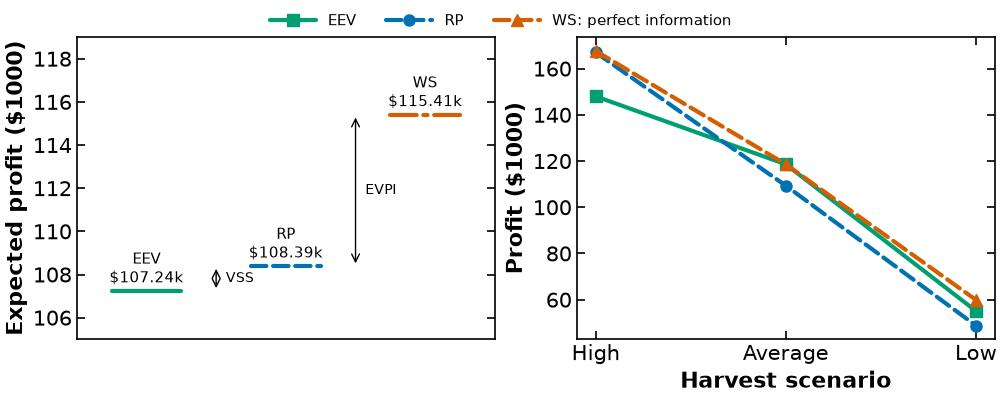

In [19]:
fig,axes=plt.subplots(1,2,figsize=(10,4),layout="constrained")
values=[results[k]/1000 for k in ["EEV","RP","WS"]]
colors=["#009E73","#0072B2","#D55E00"]
for i,(value,label,color) in enumerate(zip(values,["EEV","RP","WS"],colors)):
    axes[0].plot([i-.25,i+.25],[value,value],color=color,linewidth=3)
    axes[0].text(i,value+.4,f"{label}\n${value:,.2f}k",ha="center",fontsize=11)
for i,label in [(0,"VSS"),(1,"EVPI")]:
    axes[0].annotate("",xy=(i+.5,values[i+1]),xytext=(i+.5,values[i]),
                     arrowprops={"arrowstyle":"<->","color":"black"})
    axes[0].text(i+.57,(values[i]+values[i+1])/2,label,fontsize=10,va="center")
axes[0].set(xlim=(-.5,2.5),ylim=(105,119),ylabel="Expected profit ($1000)",xticks=[])
for label,key,marker,color in [("EEV","eev","s",colors[0]),("RP","rp","o",colors[1])]:
    p=[s["profit"]/1000 for s in results[key]["scenarios"]]
    axes[1].plot([0,1,2],p,marker=marker,label=label,color=color)
axes[1].plot([0,1,2],[r["expected_profit"]/1000 for r in results["perfect"]],
             marker="^",linestyle="--",color=colors[2],label="WS: perfect information")
axes[1].set(xticks=[0,1,2],xticklabels=["High","Average","Low"],
            xlabel="Harvest scenario",ylabel="Profit ($1000)")
fig.legend(*axes[1].get_legend_handles_labels(),loc="outside upper center",ncol=3,fontsize=11)
helper.save_figure(fig,"farmer-information-values")
